<a href="https://colab.research.google.com/github/mouali-web/MPM_200_ALi/blob/main/copy_of_01_Assignment_Logistic_Regression_Mourad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Instructions
* For all questions, you must show your work. This will enable us to understand your thought process, give partial credit, and prevent crude cheating.
* Please ensure that you are not simply copying each other's code but rather striving to understand and learn from the work.
* Provide the R code at the end of your solution and include R commands along with R outputs to clearly describe your solutions.

### Dataset Overview
* The dataset contains information about medical diagnostic measurements for predicting diabetes in Pima Indian women. The outcome variable is `Outcome`, where:
* 1 indicates diabetes-positive.
* 0 indicates diabetes-negative.

**The dataset includes the following variables:**

* `Pregnancies`: Number of pregnancies.
* `Glucose`: Plasma glucose concentration.
* `BloodPressure`: Diastolic blood pressure (mm Hg).
* `SkinThickness`: Triceps skinfold thickness (mm).
* `Insulin`: 2-Hour serum insulin (mu U/ml).
* `BMI`: Body mass index (weight in kg/(height in m)^2).
* `DiabetesPedigreeFunction`: Diabetes pedigree function (genetic risk).
* `Age`: Age (years).
* `Outcome`: Binary outcome (0 or 1).

`Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.`

## Questions

### Q0: Install necessary packages
Install and load the following packages:
`tidyverse`
`dplyr`
`ggplot2`

In [ ]:
install.packages("tidyverse")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Q1: Load the dataset
* Read the Pima Indians Diabetes Database into R.  
Points: 2

In [2]:
# First uploadig the csv file and then copying the path
data <- read.csv("/content/diabetes.csv")

Answer here

In [3]:
# Renaming the data into diabetes
diabetes <- data

### Q2: Explore the dataset
1. How many rows and columns are in the dataset?
2. How many columns are categorical, and how many are continuous?
Points: 3

### Q3: Create a random subset
Create a random subset of 500 rows from the dataset using the following code:

In [4]:
#How many rows
nrow(diabetes)


[1] 768

In [5]:
#How many columns
ncol(data)

[1] 9

In [6]:
sapply(diabetes, class) # shows type of every column

Pregnancies                  Glucose            BloodPressure 
               "integer"                "integer"                "integer" 
           SkinThickness                  Insulin                      BMI 
               "integer"                "integer"                "numeric" 
DiabetesPedigreeFunction                      Age                  Outcome 
               "numeric"                "integer"                "integer"

In [7]:
lapply(diabetes, class)

$Pregnancies
[1] "integer"

$Glucose
[1] "integer"

$BloodPressure
[1] "integer"

$SkinThickness
[1] "integer"

$Insulin
[1] "integer"

$BMI
[1] "numeric"

$DiabetesPedigreeFunction
[1] "numeric"

$Age
[1] "integer"

$Outcome
[1] "integer"

Answer Q2:

Q2.1- The data has **768** rows and **9** columns (variables)

Q2.2- 8 numeric/ continous variables. There are no factor variables, Only the outcome is the **Binary** categorical variable with two possible numeric values (0 for non-diabetes and 1 for diabetes)

Use this subset (`model_data`) for all subsequent questions.  
Points: 1

In [12]:
#Creating a random subset of 500 rows from the dataset:
set.seed(123)
subset_diabetes <- diabetes[sample(nrow(diabetes), 500), ]

In [13]:
str(subset_diabetes)

'data.frame':	500 obs. of  9 variables:
 $ Pregnancies             : int  0 8 5 3 8 5 14 4 6 1 ...
 $ Glucose                 : int  138 74 143 87 85 78 100 197 119 189 ...
 $ BloodPressure           : int  60 70 78 60 55 48 78 70 50 60 ...
 $ SkinThickness           : int  35 40 0 18 20 0 25 39 22 23 ...
 $ Insulin                 : int  167 49 0 0 0 0 184 744 176 846 ...
 $ BMI                     : num  34.6 35.3 45 21.8 24.4 33.7 36.6 36.7 27.1 30.1 ...
 $ DiabetesPedigreeFunction: num  0.534 0.705 0.19 0.444 0.136 ...
 $ Age                     : int  21 39 47 21 42 25 46 31 33 59 ...
 $ Outcome                 : int  1 0 0 0 0 0 1 0 1 1 ...


In [14]:
dim(subset_diabetes)        # should show 500 rows
nrow(subset_diabetes)       # confirms 500 rows
head(subset_diabetes)       # preview first 6 rows

[1] 500   9

[1] 500

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
415,0,138,60,35,167,34.6,0.534,21,1
463,8,74,70,40,49,35.3,0.705,39,0
179,5,143,78,0,0,45.0,0.190,47,0
526,3,87,60,18,0,21.8,0.444,21,0
195,8,85,55,20,0,24.4,0.136,42,0
118,5,78,48,0,0,33.7,0.654,25,0


### Q4: Tabulate and visualize the outcome variable
1. Tabulate and plot the distribution of the outcome variable (Outcome).  
2. Save this plot as a PDF file (4 inches wide, 3 inches tall) and submit it along with your assignment.
Points: 3



In [19]:
# Q4.1. Tabulate the outcome
table(subset_diabetes$Outcome)


  0   1 
322 178 

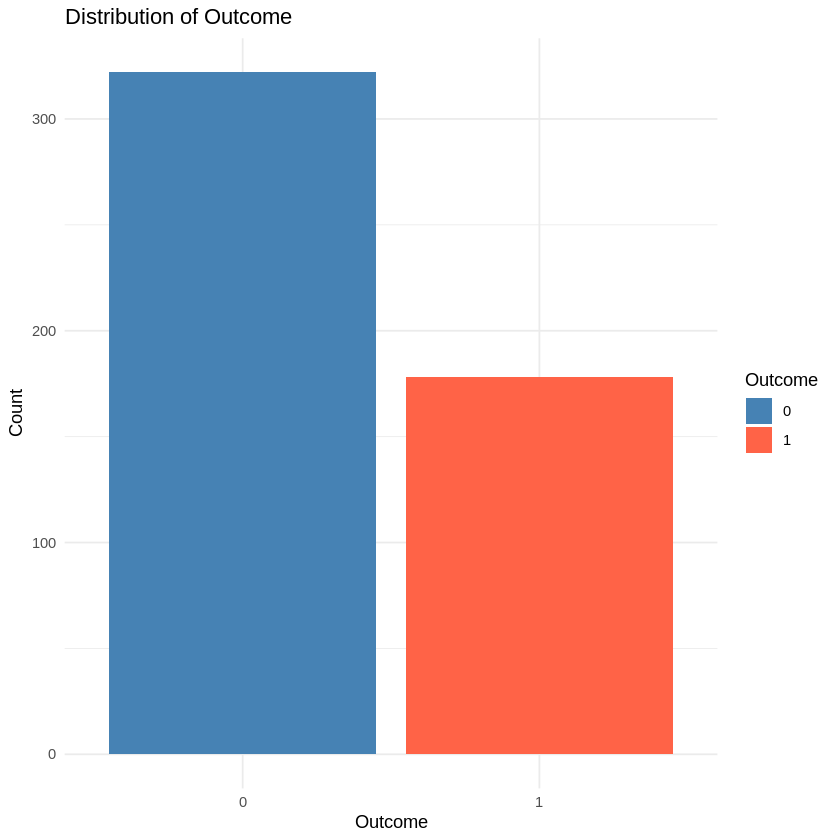

In [20]:
# Q4.2 plot the distribution of the outcome
ggplot(subset_diabetes, aes(x = factor(Outcome), fill = factor(Outcome))) +
  geom_bar() +
  labs(title = "Distribution of Outcome",
       x = "Outcome",
       y = "Count",
       fill = "Outcome") +
  scale_fill_manual(values = c("steelblue", "tomato")) +
  theme_minimal()


In [21]:
# Making pdf file 3*4 inches
pdf("outcome_plot.pdf", width = 4, height = 3)

barplot(table(subset_diabetes$Outcome),
        main = "Distribution of Outcome",
        xlab = "Outcome",
        ylab = "Count",
        col = c("steelblue", "tomato"))

dev.off()

agg_record_35712921ba 
                    2

### Q5: Explore covariates
1. Choose five covariates that you think might affect diabetes prediction based on general understanding.
2. For each covariate, create a table showing the distribution of values for each outcome (0 or 1).
3. Generate bar plots for these covariates using facet_grid in ggplot2.
Points: 5



**Answer Q5.1:**
Five covariates that you think might affect diabetes prediction:

---




  1-Glucose

  2-Insulin

  3-BMI

  4-DiabetesPedigreeFunction

  5-Age


In [34]:
subset_diabetes %>%
  group_by(Outcome) %>%
  summarise(
    n = n(),
    mean_glucose = mean(Glucose, na.rm = TRUE),
    sd_glucose = sd(Glucose, na.rm = TRUE),
    min_glucose = min(Glucose, na.rm = TRUE),
    max_glucose = max(Glucose, na.rm = TRUE)
  )

Outcome,n,mean_glucose,sd_glucose,min_glucose,max_glucose
<int>,<int>,<dbl>,<dbl>,<int>,<int>
0,322,110.6739,26.21269,0,197
1,178,142.2753,32.29993,0,199


In [31]:
glucose_distribution <- subset_diabetes %>%
  group_by(Outcome, Glucose) %>%
  summarise(count = n(), .groups = 'drop')
print(glucose_distribution)

# A tibble: 187 × 3
   Outcome Glucose count
     <int>   <int> <int>
 1       0       0     2
 2       0      56     1
 3       0      57     1
 4       0      61     1
 5       0      65     1
 6       0      67     1
 7       0      68     1
 8       0      71     2
 9       0      72     1
10       0      73     2
# ℹ 177 more rows


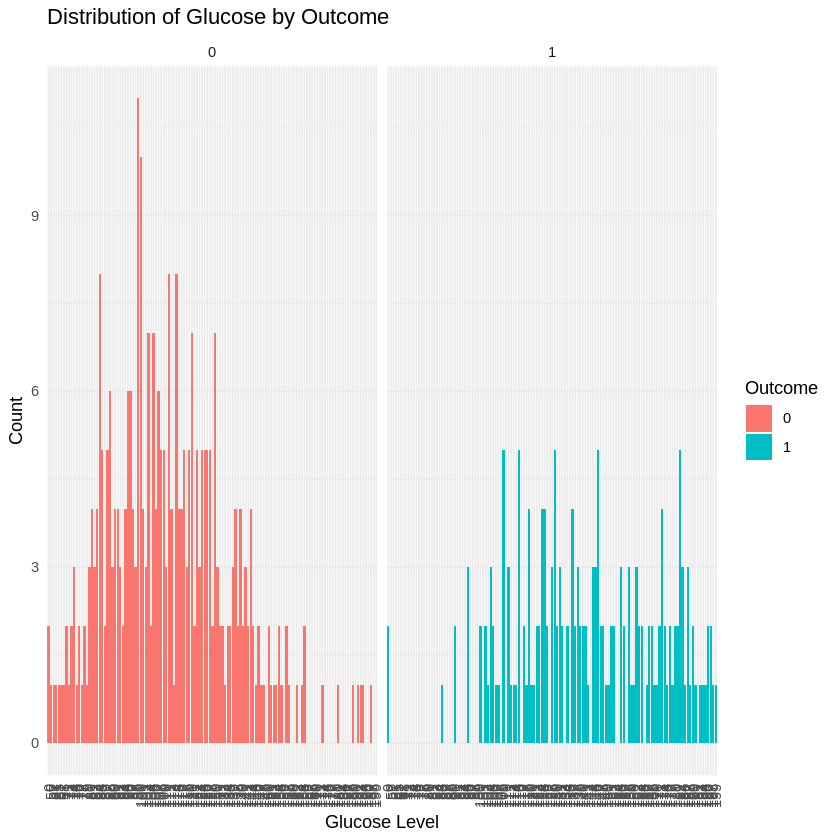

In [33]:
# Q5.3: Generate bar plot for Glucose using facet_grid
ggplot(glucose_distribution, aes(x = factor(Glucose), y = count, fill = factor(Outcome))) +
  geom_bar(stat = "identity", position = "dodge") +
  facet_grid(. ~ Outcome) +
  labs(title = "Distribution of Glucose by Outcome",
       x = "Glucose Level",
       y = "Count",
       fill = "Outcome") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1)) # Rotate x-axis labels for readability

In [29]:
# Q5.2: Create tables showing the distribution of values for each outcome (0 or 1)
# The selected covariates are Glucose, Insulin, BMI, DiabetesPedigreeFunction, Age

# Table for Glucose
glucose_outcome_table <- table(Outcome = subset_diabetes$Outcome, Glucose = subset_diabetes$Glucose)
cat("\nDistribution of Glucose by Outcome:\n")
print(glucose_outcome_table)

# Table for Insulin
insulin_outcome_table <- table(Outcome = subset_diabetes$Outcome, Insulin = subset_diabetes$Insulin)
cat("\nDistribution of Insulin by Outcome:\n")
print(insulin_outcome_table)

# Table for BMI
bmi_outcome_table <- table(Outcome = subset_diabetes$Outcome, BMI = subset_diabetes$BMI)
cat("\nDistribution of BMI by Outcome:\n")
print(bmi_outcome_table)

# Table for DiabetesPedigreeFunction
dpf_outcome_table <- table(Outcome = subset_diabetes$Outcome, DiabetesPedigreeFunction = subset_diabetes$DiabetesPedigreeFunction)
cat("\nDistribution of DiabetesPedigreeFunction by Outcome:\n")
print(dpf_outcome_table)

# Table for Age
age_outcome_table <- table(Outcome = subset_diabetes$Outcome, Age = subset_diabetes$Age)
cat("\nDistribution of Age by Outcome:\n")
print(age_outcome_table)


Distribution of Glucose by Outcome:
       Glucose
Outcome  0 56 57 61 65 67 68 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87
      0  2  1  1  1  1  1  1  2  1  2  3  1  2  1  2  1  3  4  3  4  8  5  2  5
      1  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0
       Glucose
Outcome 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108
      0  6  3  4  4  3  2  4  6  6  4  3 11  10   4   3   7   2   7   4   6   5
      1  0  0  2  0  0  0  0  3  0  0  0  0   2   0   2   1   3   2   1   1   0
       Glucose
Outcome 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
      0   5   3   8   4   1   8   4   4   5   3   5   7   2   5   3   5   5   5
      1   5   0   3   1   1   1   5   0   2   1   4   1   1   2   2   4   4   2
       Glucose
Outcome 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
      0   5   2   7   3   2   2   1   2   2   3   4   2   4   2   3   2   4   2
      1   0   3   5   2

In [25]:
# For create a table showing the distribution of values for each outcome (0 or 1)one variable at a time
glucose_table <-table(subset_diabetes$Outcome, subset_diabetes$Glucose)
addmargins(glucose_table)

,0,56,57,61,65,67,68,71,72,73,⋯,190,191,193,194,195,196,197,198,199,Sum
0,2,1,1,1,1,1,1,2,1,2,⋯,0,1,1,1,0,0,1,0,0,322
1,2,0,0,0,0,0,0,0,0,0,⋯,1,0,1,1,1,2,2,1,1,178
Sum,4,1,1,1,1,1,1,2,1,2,⋯,1,1,2,2,1,2,3,1,1,500


In [27]:
insulin_table <-table(subset_diabetes$Outcome, subset_diabetes$Insulin)
addmargins(insulin_table)

,0,14,16,18,22,25,32,36,37,38,⋯,478,480,495,510,540,545,680,744,846,Sum
0,149,0,1,1,1,1,1,2,1,1,⋯,0,0,0,0,0,1,1,1,0,322
1,90,1,0,0,0,0,0,1,0,0,⋯,1,1,2,1,1,0,0,0,1,178
Sum,239,1,1,1,1,1,1,3,1,1,⋯,1,1,2,1,1,1,1,1,1,500


## Q6: Understanding the problem
1. What is the outcome variable in this dataset?
2. Is the outcome continuous, count, or binary?
3. Based on this, which type of GLM family is appropriate?

**Answer Q6**:


---


1- The outcome variable is the diabetes status (Outcome)

2- The outcome is binary taking two values (0 for non-diabetes and 1 for diabetes)

3- Logistic regression is the best fit for this type of outcome


## Q7 Writing the model
1. Write the mathematical form of the model:
2. What is being modeled on the left-hand side?
3. What transformation is applied (logit)?
4. How would you express (logit) this in words?

Answer Q7:


---


1- log(p/1-p​)=β0​+β1​X1​+β2​X2​+...+βnXn

2- Log-Odds or The natural log of the odds of the outcome

3- Log transformation

4- The natural log of the odds that the outcome equals 1


### Q7: Run univariate logistic regression models
1. Perform univariate logistic regression for each of the five selected covariates using the `glm()` function with a binomial family.
2. Identify which variable has the highest beta coefficient and explain its significance.
Points: 10



**Answer Q7.2**:


---
DiabetesPedigreeFunction has the highest beta coefficient of **0.8897** among all covariates in the univariate logistic regression.

For every one unit increase in DiabetesPedigreeFunction, the log-odds of having diabetes increases by 0.8897, holding everything else constant.

Glucose      0.038691

Insulin      0.0023260

Age          0.041934

BMI          0.09250

DiabetesPedigreeFunction   0.8897






In [37]:
# Glucose
model_glucose <- glm(Outcome ~ Glucose,
                     data = subset_diabetes,
                     family = binomial)
summary(model_glucose)

# Insulin
model_insulin <- glm(Outcome ~ Insulin,
                     data = subset_diabetes,
                     family = binomial)
summary(model_insulin)

# Age
model_age <- glm(Outcome ~ Age,
                 data = subset_diabetes,
                 family = binomial)
summary(model_age)

# BMI
model_bmi <- glm(Outcome ~ BMI,
                 data = subset_diabetes,
                 family = binomial)
summary(model_bmi)

# DiabetesPedigreeFunction
model_dpf <- glm(Outcome ~ DiabetesPedigreeFunction,
                 data = subset_diabetes,
                 family = binomial)
summary(model_dpf)




Call:
glm(formula = Outcome ~ Glucose, family = binomial, data = subset_diabetes)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -5.458299   0.534501  -10.21   <2e-16 ***
Glucose      0.038691   0.004107    9.42   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 527.29  on 498  degrees of freedom
AIC: 531.29

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ Insulin, family = binomial, data = subset_diabetes)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.7901977  0.1164393  -6.786 1.15e-11 ***
Insulin      0.0023260  0.0007918   2.938  0.00331 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 642.16  on 498  degrees of freedom
AIC: 646.16

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ Age, family = binomial, data = subset_diabetes)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.008000   0.296236  -6.778 1.22e-11 ***
Age          0.041934   0.008224   5.099 3.41e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 623.69  on 498  degrees of freedom
AIC: 627.69

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ BMI, family = binomial, data = subset_diabetes)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -3.63118    0.50357  -7.211 5.56e-13 ***
BMI          0.09250    0.01482   6.241 4.36e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 603.74  on 498  degrees of freedom
AIC: 607.74

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ DiabetesPedigreeFunction, family = binomial, 
    data = subset_diabetes)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -1.0310     0.1644  -6.271 3.59e-10 ***
DiabetesPedigreeFunction   0.8897     0.2702   3.292 0.000994 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 639.80  on 498  degrees of freedom
AIC: 643.8

Number of Fisher Scoring iterations: 4


### Q8: Interpret odds ratios
1. For each covariate in your final model:
2. Calculate odds ratios manually from model coefficients.
3. Interpret these odds ratios in words, considering whether they are statistically significant.
4. Use `sjPlot::tab_model()` to verify your calculations and compare results.
Points: 10



**Answer Q8**:


---



### Q9: Model diagnostics (do not attempt, for next assingment)
1. How many properties can you access from a fitted logistic regression model object in R? Use names(YOURMODEL) to explore.
2. Discuss any two properties that provide insights into model performance or interpretation.
3. What is deviance for your model?
4. What does a large reduction in deviance indicate?
5. How does deviance relate to:  
  model fit?  
  likelihood?  
Points: 10



## Q10 : Perform Residual diagnostics (do not attempt, for next assingment)
1. What types of residuals are available in GLMs?
2. Why do residual plots look different for binary outcomes?
3. Why do we see two bands in residual plots?
4. Which residual is generally preferred for GLMs and why?

## Q11: Run analysis for Influential observations using Cook's distance calculations (do not attempt, for next assingment))
1. What is Cook’s Distance measuring?
2. What does a large Cook’s Distance imply?
3. Should influential points always be removed? Why or why not?

## Q12: Run Model calibration for your model and data (do not attempt, for next assingment))
1. What does calibration mean in logistic regression?

### Q13: Final interpretation
Based on your analysis:
1. Which variable has the highest odds ratio for predicting diabetes?
2. Write down statistical interpretation of this odds ratio.  
Points: 10

## Bonus Question:
Manully code IRLS method to fit your logistic regression and compare the results with results from `glm()` function